# Sprint 1 — EDA y Definición de Churn · Dataset Olist
Nelson123!

**Proyecto:** Análisis de Propensión al Churn de Clientes — Olist Brazilian E-Commerce
**Módulo:** Implementación de Soluciones de IA Aplicada a los Negocios — Caso Nº 7
**Sprint 1 — v3:** Definición del problema y EDA · Horizonte **H = 90 días**

> **Versión 3:** idéntica a la v1 en análisis, pero **lee las tablas desde Azure SQL Database** (`OlistDB`) en lugar de CSV. Esta es la fuente persistente para la simulación mensual del Sprint 2 (basta filtrar por fecha en el `SELECT`).

---

## Hallazgo central del EDA (resumen ejecutivo)
La definición clásica de churn por ventana (*no comprar en los próximos H días*) resulta
**degenerada** en Olist: ~97-99 % de positivos en cualquier población. El motivo es estructural:
**el 96,96 % de los clientes compra una sola vez**. Por eso este notebook:

1. Demuestra la degeneración de `is_churn` por ventana y lo conserva solo como **métrica de negocio**.
2. Adopta como **target del MVP** la **propensión a recompra** (`is_repeat`): ¿el cliente vuelve a comprar?
3. Contrasta las hipótesis contra ese target y **descarta** las que la evidencia no sostiene.

## Hipótesis de trabajo (refinadas — se contrastan en la sección 14)
- **H1 — Recencia:** ↑recencia ⇒ ↑abandono *(mecánica)*.
- **H2 — Historial de compra:** tener ≥2 pedidos previos es el predictor estructural dominante.
- **H3 — Características del 1er pedido (nueva):** nº de ítems y valor se asocian con la recompra.
- **H4 — Categoría (reformulada):** la categoría del 1er producto modula la recompra.
- **H5 — Geografía/distancia:** estado y distancia vendedor–cliente se asocian con el abandono.
- **Variables de control (descartadas como centrales):** entrega tardía y reseña **no** predicen
  la recompra; se conservan como controles y se advierte el *artefacto de medias-estrellas*.

## El reto particular de Olist
`customer_id` es único por pedido; la persona real es **`customer_unique_id`** (todo se agrega por él).
El churn es temporal → partición **cronológica** (out-of-time), nunca aleatoria.


## 1. Configuración del entorno

Imports, opciones de display y **parámetros globales**. Rutas **relativas**: `Data/` está al
mismo nivel que `Notebooks/`, por lo que se accede con `../Data`.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 120)

DATA_DIR         = '../Data'        # Data al mismo nivel que Notebooks
H                = 90               # horizonte (días)
FECHA_CORTE_DEMO = pd.Timestamp('2018-05-31')
RANDOM_STATE     = 42
ESTADOS_INVALIDOS = ['canceled', 'unavailable']   # se excluyen de la señal de compra

print('pandas', pd.__version__, '| numpy', np.__version__)
print('H =', H, 'días | corte demo =', FECHA_CORTE_DEMO.date())

pandas 3.0.3 | numpy 2.4.6
H = 90 días | corte demo = 2018-05-31


### 2.0. Conexión a Azure SQL Database  *(novedad de la v3)*

Las tablas se leen desde `OlistDB` en tu servidor de Azure SQL (creado con `azure_sql_setup.ps1`
y cargado con `cargar_sql_desde_blob.py`). El notebook toma servidor/base/usuario de
`sql_conexion.txt` (o de las variables de abajo) y pide la contraseña con `getpass`.

**Requisitos:** `pip install sqlalchemy pyodbc` y el **ODBC Driver 18 for SQL Server**
(https://aka.ms/odbc18). La base es *serverless* con auto-pausa: la primera consulta tras un
rato de inactividad puede tardar unos segundos en "despertar".

In [2]:
# === Conexión a Azure SQL Database (v3) ===
import os, getpass, urllib.parse, subprocess, sys
try:
    from sqlalchemy import create_engine, text
    import pyodbc
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'sqlalchemy', 'pyodbc', '-q'])
    from sqlalchemy import create_engine, text
    import pyodbc

# Datos de conexión (de azure_sql_setup.ps1). Se leen de sql_conexion.txt si existe.
SQL_SERVER = 'olist-sql-40548.database.windows.net'
SQL_DB     = 'OlistDB'
SQL_ADMIN  = 'olistadmin'
if os.path.exists('sql_conexion.txt'):
    for _l in open('sql_conexion.txt', encoding='utf-8'):
        if '=' in _l:
            _k, _v = _l.strip().split('=', 1)
            if _k == 'SQL_SERVER': SQL_SERVER = _v
            if _k == 'SQL_DB':     SQL_DB = _v
            if _k == 'SQL_ADMIN':  SQL_ADMIN = _v

PWD = os.environ.get('AZURE_SQL_PASSWORD') or getpass.getpass(f'Contraseña de {SQL_ADMIN}: ')
driver = 'ODBC Driver 18 for SQL Server'
if driver not in pyodbc.drivers():
    driver = 'ODBC Driver 17 for SQL Server'
odbc = (f'Driver={{{driver}}};Server=tcp:{SQL_SERVER},1433;Database={SQL_DB};'
        f'Uid={SQL_ADMIN};Pwd={PWD};Encrypt=yes;TrustServerCertificate=no;Connection Timeout=60;')
engine = create_engine('mssql+pyodbc:///?odbc_connect=' + urllib.parse.quote_plus(odbc))

def load_table(tabla, parse_dates=None):
    """Lee una tabla completa de Azure SQL a un DataFrame.
    En Sprint 2 puedes pasar un SELECT con WHERE para traer solo hasta la fecha de corte."""
    df = pd.read_sql(f'SELECT * FROM {tabla}', engine)
    for c in (parse_dates or []):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

with engine.connect() as _cx:
    _tabs = [r[0] for r in _cx.execute(text('SELECT name FROM sys.tables ORDER BY name'))]
print('Conectado a Azure SQL:', SQL_SERVER, '/', SQL_DB)
print('Tablas disponibles:', _tabs)

Conectado a Azure SQL: olist-sql-40548.database.windows.net / OlistDB
Tablas disponibles: ['category_translation', 'customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'orders', 'products', 'sellers']


## 2. Carga de datos

Se leen las tablas necesarias; en `orders` se parsean las 5 columnas de fecha. La
geolocalización se carga desde el **resumen** `geolocation_zip_lookup.csv` (ver 2.1).

In [3]:
# Lectura desde Azure SQL (en vez de CSV). Las fechas se reparsean por seguridad.
orders    = load_table('orders', parse_dates=['order_purchase_timestamp','order_approved_at',
              'order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date'])
customers = load_table('customers')
items     = load_table('order_items', parse_dates=['shipping_limit_date'])
payments  = load_table('order_payments')
reviews   = load_table('order_reviews', parse_dates=['review_creation_date','review_answer_timestamp'])
products  = load_table('products')
sellers   = load_table('sellers')
cat_trans = load_table('category_translation')
geo       = load_table('geolocation')

tablas = {'orders':orders,'customers':customers,'items':items,'payments':payments,
          'reviews':reviews,'products':products,'sellers':sellers,
          'cat_trans':cat_trans,'geo':geo}
pd.DataFrame({'filas':[len(t) for t in tablas.values()],
              'columnas':[t.shape[1] for t in tablas.values()]}, index=tablas.keys())

,filas,columnas
orders,99441,8
customers,99441,5
items,112650,7
payments,103886,5
reviews,99224,7
products,32951,9
sellers,3095,4
cat_trans,71,2
geo,19015,5


### 2.1. Archivo de coordenadas resumido

La tabla cruda `olist_geolocation_dataset.csv` pesa **61,3 MB** (1.000.163 filas, muchas
coordenadas por prefijo). Se resume a `geolocation_zip_lookup.csv` (**19.015 prefijos, 1,12 MB,
−98,2 %**): mediana de lat/lng + ciudad/estado modal. Si no existe, la celda lo genera.

In [4]:
# La tabla geolocation ya se cargó desde Azure SQL (celda anterior).
geo = geo.rename(columns={'geolocation_zip_code_prefix':'zip_prefix'})
geo.head()

,zip_prefix,lat,lng,state,city
0,1001,-23.550381,-46.634027,SP,sao paulo
1,1002,-23.548551,-46.635072,SP,sao paulo
2,1003,-23.548977,-46.635313,SP,sao paulo
3,1004,-23.549535,-46.634771,SP,sao paulo
4,1005,-23.549612,-46.636532,SP,sao paulo


## 3. Diccionario de datos y tipos

In [5]:
orders.info()
print('\nEstados de pedido:'); print(orders['order_status'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB

Estados de pedido:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            

## 4. Calidad de datos

Faltantes por columna. Las fechas de entrega nulas corresponden a pedidos **no entregados**
(cancelados/en proceso), no a errores.

In [6]:
falt = (orders.isna().mean()*100).round(2).sort_values(ascending=False)
print('% faltantes en orders:'); print(falt[falt>0])
print('\nPedidos duplicados:', orders['order_id'].duplicated().sum())
print('Items sin pedido en orders:', (~items['order_id'].isin(orders['order_id'])).sum())

% faltantes en orders:
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
dtype: float64

Pedidos duplicados: 0
Items sin pedido en orders: 0


## 5. Resolución de identidad del cliente

`customer_id` cambia en cada compra; la persona real es `customer_unique_id`. Se excluyen
pedidos `canceled`/`unavailable` para la señal de compra y se mide la **tasa de recompra**.

In [7]:
oc = orders.merge(customers, on='customer_id', how='left')
oc_valid = oc[~oc['order_status'].isin(ESTADOS_INVALIDOS)].copy()

por_id  = oc_valid.groupby('customer_id')['order_id'].nunique()
por_uid = oc_valid.groupby('customer_unique_id')['order_id'].nunique()
print('Con customer_id  -> % "una sola compra":', round((por_id==1).mean()*100,2),'%  (engañoso)')
print('Con customer_unique_id -> % una sola compra:', round((por_uid==1).mean()*100,2),'%')
print('Clientes reales:', por_uid.shape[0])
print('Tasa de recompra (>=2 compras):', round((por_uid>=2).mean()*100,2),'%')
print('Distribución nº compras:', por_uid.value_counts().head(5).to_dict())

Con customer_id  -> % "una sola compra": 100.0 %  (engañoso)
Con customer_unique_id -> % una sola compra: 96.96 %
Clientes reales: 94990
Tasa de recompra (>=2 compras): 3.04 %
Distribución nº compras: {1: 92102, 2: 2652, 3: 188, 4: 29, 5: 9}


## 6. Tabla cliente-pedido base (orders_enriched)

Tabla a **nivel de pedido válido** con valor, nº de ítems, reseña, métricas de entrega,
categoría, tipo de pago y **distancia vendedor–cliente**. Es la base de RFM, las hipótesis
y ambos targets.

In [8]:
def dominante(df, key, col):
    '''Valor modal de `col` por `key`, vectorizado (rápido).'''
    c = (df.dropna(subset=[col]).groupby([key, col]).size().reset_index(name='n')
           .sort_values('n').drop_duplicates(key, keep='last'))
    return c.set_index(key)[col]

# valor y nº de ítems por pedido
val = items.groupby('order_id').agg(price=('price','sum'), freight=('freight_value','sum'),
                                    n_items=('order_item_id','max')).reset_index()
val['valor'] = val['price'] + val['freight']
# tipo de pago dominante / reseña media
pay = (payments.sort_values('payment_value', ascending=False)
       .groupby('order_id').agg(tipo_pago=('payment_type','first')).reset_index())
rev = reviews.groupby('order_id')['review_score'].mean().reset_index()
# categoría dominante por pedido (traducida)
it_cat = (items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
               .merge(cat_trans, on='product_category_name', how='left'))
it_cat['categoria'] = it_cat['product_category_name_english'].fillna(it_cat['product_category_name'])
cat_ord = dominante(it_cat, 'order_id', 'categoria').reset_index()

# distancia vendedor-cliente (haversine) via lookup
def haversine(lat1,lon1,lat2,lon2):
    R=6371.0; p1,p2=np.radians(lat1),np.radians(lat2)
    dphi=np.radians(lat2-lat1); dl=np.radians(lon2-lon1)
    a=np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))
geo_s=geo.rename(columns={'zip_prefix':'seller_zip_code_prefix','lat':'s_lat','lng':'s_lng'})
geo_c=geo.rename(columns={'zip_prefix':'customer_zip_code_prefix','lat':'c_lat','lng':'c_lng'})
it_sel=(items.merge(sellers[['seller_id','seller_zip_code_prefix']],on='seller_id',how='left')
             .merge(geo_s[['seller_zip_code_prefix','s_lat','s_lng']],on='seller_zip_code_prefix',how='left'))
ord_cust=oc_valid[['order_id','customer_unique_id','customer_zip_code_prefix','customer_state']]
it_sel=it_sel.merge(ord_cust[['order_id','customer_zip_code_prefix']],on='order_id',how='left')              .merge(geo_c[['customer_zip_code_prefix','c_lat','c_lng']],on='customer_zip_code_prefix',how='left')
it_sel['dist_km']=haversine(it_sel['s_lat'],it_sel['s_lng'],it_sel['c_lat'],it_sel['c_lng'])
dist_ord=it_sel.groupby('order_id')['dist_km'].mean().reset_index()

# nivel pedido válido
oe=oc_valid[['order_id','customer_unique_id','customer_state','order_status',
             'order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']].copy()
oe['retraso_dias']=(oe['order_delivered_customer_date']-oe['order_estimated_delivery_date']).dt.days
oe['tardio']=(oe['retraso_dias']>0).astype('float')
oe.loc[oe['order_delivered_customer_date'].isna(),'tardio']=np.nan
orders_enriched=(oe.merge(val[['order_id','valor','n_items']],on='order_id',how='left')
                   .merge(rev,on='order_id',how='left').merge(cat_ord,on='order_id',how='left')
                   .merge(pay,on='order_id',how='left').merge(dist_ord,on='order_id',how='left'))
print('orders_enriched:', orders_enriched.shape)
orders_enriched.head(3)

orders_enriched: (98207, 15)


,order_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,retraso_dias,tardio,valor,n_items,review_score,categoria,tipo_pago,dist_km
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,-8.0,0.0,38.71,1.0,4.0,housewares,voucher,18.681711
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,-6.0,0.0,141.46,1.0,4.0,perfumery,boleto,861.035367
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,-18.0,0.0,179.12,1.0,5.0,auto,credit_card,514.547140


## 7. EDA descriptivo (univariado)

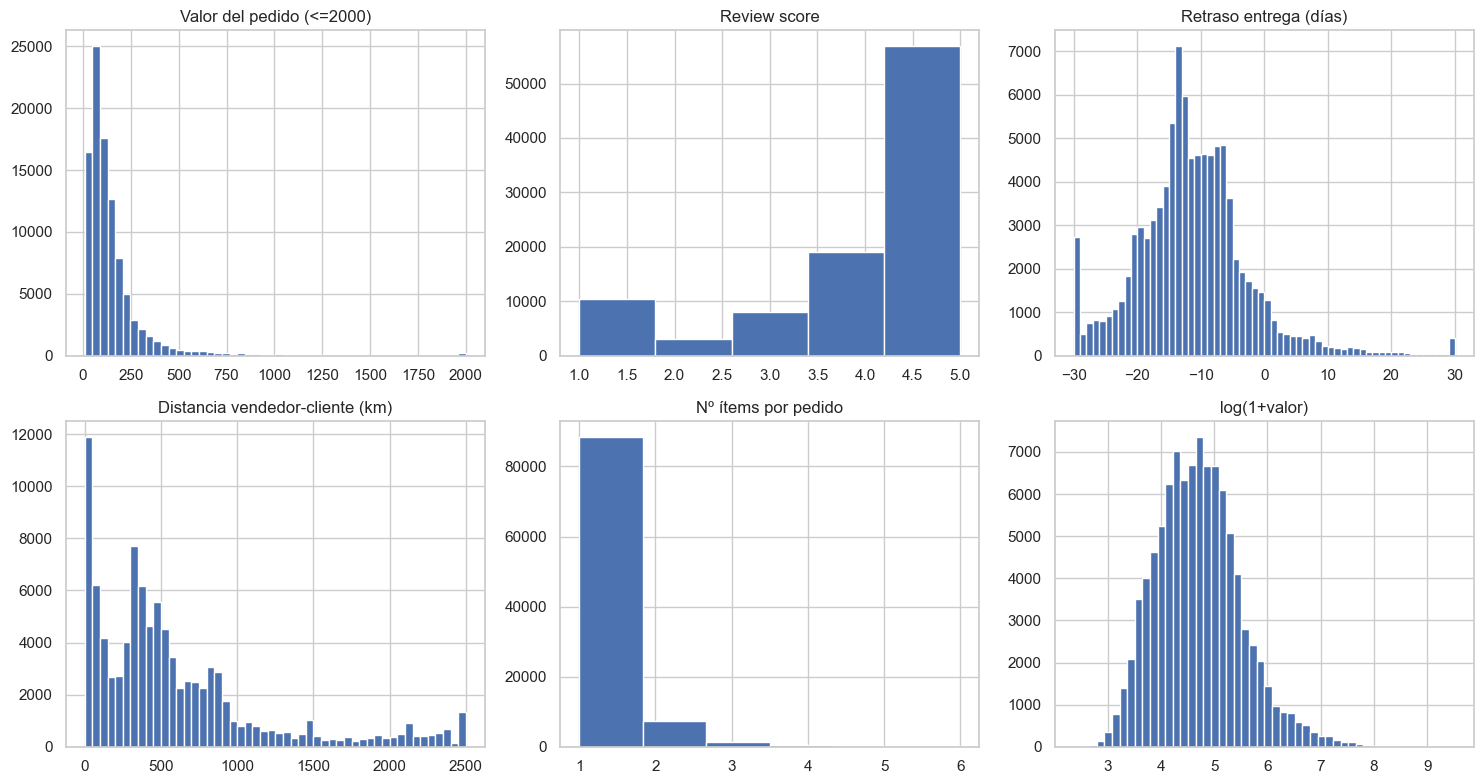

,valor,n_items,review_score,retraso_dias,dist_km
count,98199.00,98199.00,97473.00,96470.00,97712.00
mean,160.24,1.14,4.12,-11.88,602.36
std,219.11,0.54,1.32,10.18,595.50
min,9.59,1.00,1.00,-147.00,0.00
25%,61.96,1.00,4.00,-17.00,188.33
50%,105.28,1.00,5.00,-12.00,434.49
75%,176.73,1.00,5.00,-7.00,799.28
max,13664.08,21.00,5.00,188.00,8677.86


In [9]:
fig, ax = plt.subplots(2,3, figsize=(15,8))
orders_enriched['valor'].clip(upper=2000).hist(bins=50, ax=ax[0,0]); ax[0,0].set_title('Valor del pedido (<=2000)')
orders_enriched['review_score'].hist(bins=5, ax=ax[0,1]); ax[0,1].set_title('Review score')
orders_enriched['retraso_dias'].clip(-30,30).hist(bins=60, ax=ax[0,2]); ax[0,2].set_title('Retraso entrega (días)')
orders_enriched['dist_km'].clip(upper=2500).hist(bins=50, ax=ax[1,0]); ax[1,0].set_title('Distancia vendedor-cliente (km)')
orders_enriched['n_items'].clip(upper=6).hist(bins=6, ax=ax[1,1]); ax[1,1].set_title('Nº ítems por pedido')
np.log1p(orders_enriched['valor']).hist(bins=50, ax=ax[1,2]); ax[1,2].set_title('log(1+valor)')
plt.tight_layout(); plt.show()
orders_enriched[['valor','n_items','review_score','retraso_dias','dist_km']].describe().round(2)

## 8. Tendencias temporales

Olist concentra su actividad entre **ene-2017 y ago-2018**; los extremos tienen pocos datos
y condicionan la partición temporal.

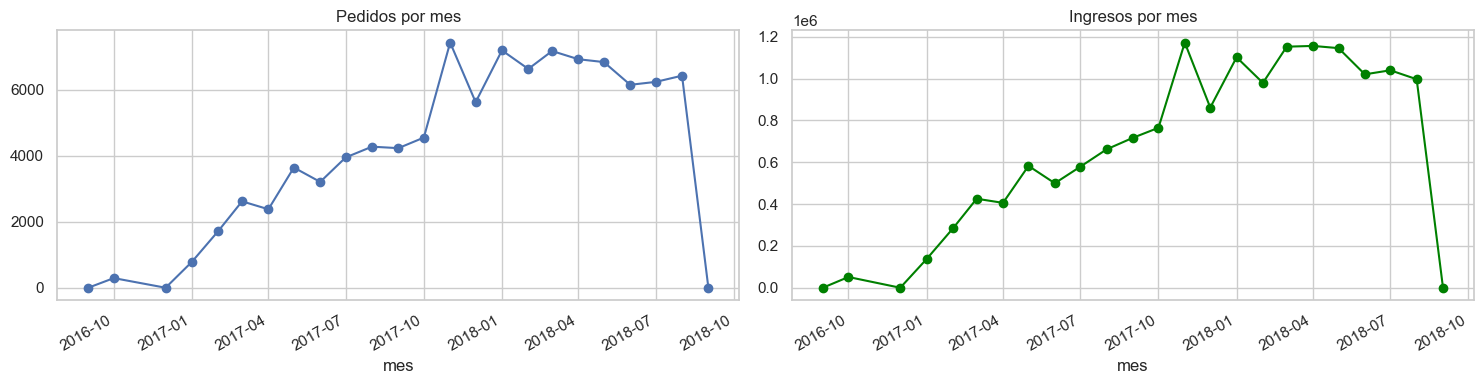

Rango de compra: 2016-09-04 21:15:19 -> 2018-10-17 17:30:18


In [10]:
tmp=orders_enriched.copy(); tmp['mes']=tmp['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
mensual=tmp.groupby('mes').agg(pedidos=('order_id','count'), ingresos=('valor','sum'))
fig, ax=plt.subplots(1,2, figsize=(15,4))
mensual['pedidos'].plot(ax=ax[0], marker='o'); ax[0].set_title('Pedidos por mes')
mensual['ingresos'].plot(ax=ax[1], marker='o', color='green'); ax[1].set_title('Ingresos por mes')
plt.tight_layout(); plt.show()
print('Rango de compra:', orders['order_purchase_timestamp'].min(), '->', orders['order_purchase_timestamp'].max())

## 9. Análisis RFM y función generadora de la tabla maestra

`build_customer_table(t, H)` calcula, anclada a una fecha de corte `t`, las features por
cliente (ventana de observación ≤ t) y la etiqueta `is_churn` por ventana (resultado en
`(t, t+H]`). Es la base reproducible y se reutiliza para mostrar la degeneración de `is_churn`
(sección 12) y para H1/H2.

Tabla maestra (corte demo): (76717, 12)


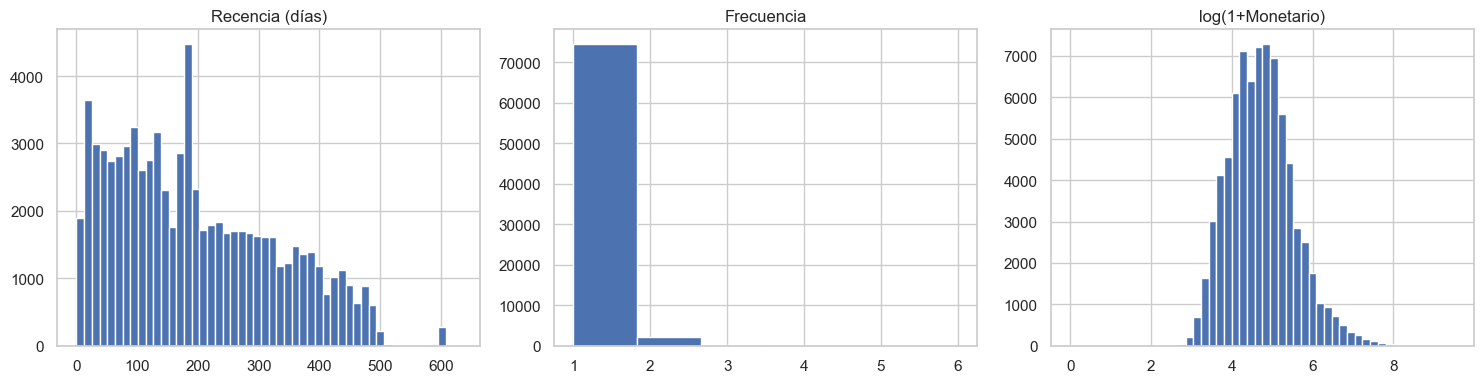

,recencia,frecuencia,monetario
count,76717.0,76717.0,76717.0
mean,194.7,1.0,164.9
std,132.4,0.2,223.4
min,0.0,1.0,0.0
25%,85.0,1.0,63.1
50%,177.0,1.0,107.4
75%,291.0,1.0,182.4
max,633.0,11.0,13664.1


In [11]:
def build_customer_table(t, H=90):
    t=pd.Timestamp(t)
    obs=orders_enriched[orders_enriched['order_purchase_timestamp']<=t]
    fut=orders_enriched[(orders_enriched['order_purchase_timestamp']>t) &
                        (orders_enriched['order_purchase_timestamp']<=t+pd.Timedelta(days=H))]
    g=obs.groupby('customer_unique_id')
    df=pd.DataFrame({
        'recencia':(t-g['order_purchase_timestamp'].max()).dt.days,
        'frecuencia':g['order_id'].nunique(),
        'monetario':g['valor'].sum(),
        'tenure':(t-g['order_purchase_timestamp'].min()).dt.days,
        'n_items_medio':g['n_items'].mean(),
        'review_mean':g['review_score'].mean(),
        'retraso_medio':g['retraso_dias'].mean(),
        'pct_tardias':g['tardio'].mean(),
        'dist_media':g['dist_km'].mean(),
    })
    df['estado']=dominante(obs,'customer_unique_id','customer_state')
    df['categoria']=dominante(obs,'customer_unique_id','categoria')
    activos=set(fut['customer_unique_id'])
    df['is_churn']=(~df.index.isin(activos)).astype(int)
    return df

maestra=build_customer_table(FECHA_CORTE_DEMO, H)
print('Tabla maestra (corte demo):', maestra.shape)
fig, ax=plt.subplots(1,3, figsize=(15,4))
maestra['recencia'].hist(bins=50, ax=ax[0]); ax[0].set_title('Recencia (días)')
maestra['frecuencia'].clip(upper=6).hist(bins=6, ax=ax[1]); ax[1].set_title('Frecuencia')
np.log1p(maestra['monetario']).hist(bins=50, ax=ax[2]); ax[2].set_title('log(1+Monetario)')
plt.tight_layout(); plt.show()
maestra[['recencia','frecuencia','monetario']].describe().round(1)

## 10. Tiempo entre compras y tiempo a la 2ª compra

Justifica `H = 90`. La mediana del tiempo a la segunda compra es ~28 días y el 68 % de las
segundas compras ocurre dentro de 90 días.

Tiempo a la 2ª compra -> mediana: 28.0 | p75: 124.25 | p90: 247.0
% 2ª compra <=90d: 68.4 | <=180d: 83.0


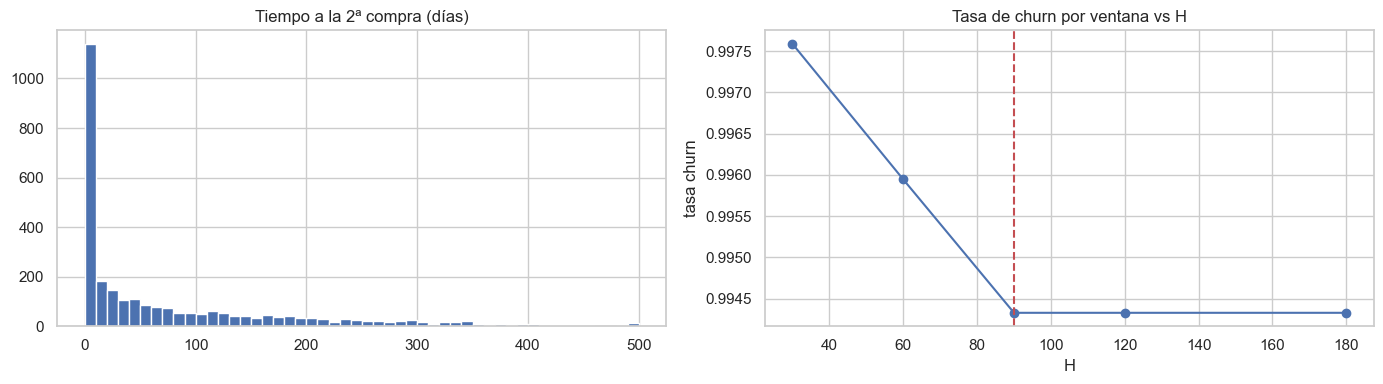

,H,tasa_churn
0,30,0.998
1,60,0.996
2,90,0.994
3,120,0.994
4,180,0.994


In [12]:
seq=orders_enriched.sort_values('order_purchase_timestamp')
seq['rank']=seq.groupby('customer_unique_id')['order_purchase_timestamp'].rank(method='first')
p1=seq[seq['rank']==1][['customer_unique_id','order_purchase_timestamp']].rename(columns={'order_purchase_timestamp':'t1'})
p2=seq[seq['rank']==2][['customer_unique_id','order_purchase_timestamp']].rename(columns={'order_purchase_timestamp':'t2'})
gap2=(p1.merge(p2,on='customer_unique_id').eval('t2-t1')).dt.days
print('Tiempo a la 2ª compra -> mediana:',gap2.median(),'| p75:',gap2.quantile(.75),'| p90:',gap2.quantile(.90))
print('% 2ª compra <=90d:',round((gap2<=90).mean()*100,1),'| <=180d:',round((gap2<=180).mean()*100,1))

def churn_rate(t,H):
    t=pd.Timestamp(t)
    obs=orders_enriched.loc[orders_enriched['order_purchase_timestamp']<=t,'customer_unique_id'].unique()
    fut=set(orders_enriched.loc[(orders_enriched['order_purchase_timestamp']>t)&
            (orders_enriched['order_purchase_timestamp']<=t+pd.Timedelta(days=H)),'customer_unique_id'])
    return float(np.mean([c not in fut for c in obs]))
sens=pd.DataFrame([(h,churn_rate(FECHA_CORTE_DEMO,h)) for h in [30,60,90,120,180]],columns=['H','tasa_churn'])
fig,ax=plt.subplots(1,2,figsize=(14,4))
gap2.clip(upper=500).hist(bins=50,ax=ax[0]); ax[0].set_title('Tiempo a la 2ª compra (días)')
ax[1].plot(sens['H'],sens['tasa_churn'],marker='o'); ax[1].axvline(90,color='r',ls='--')
ax[1].set_title('Tasa de churn por ventana vs H'); ax[1].set_xlabel('H'); ax[1].set_ylabel('tasa churn')
plt.tight_layout(); plt.show(); sens.round(3)

## 11. Recompra por cohortes y por categoría  *(NUEVA)*

Retención por cohorte de primera compra y **tasa de recompra según la categoría del primer
pedido**. La categoría sí modula la recompra (1,9 %–4,6 %) → sustenta H4.

Clientes: 94990 | tasa de recompra (is_repeat): 3.04 %


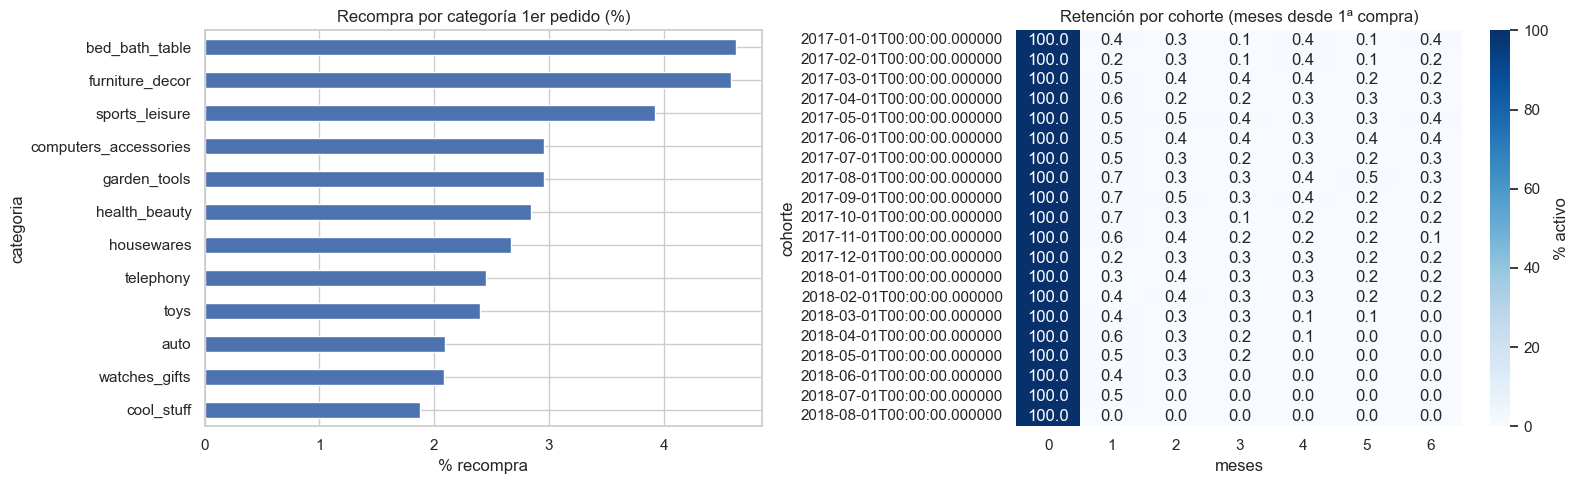

In [13]:
# --- construir tabla cliente a partir del PRIMER pedido (base del target is_repeat) ---
ncomp = orders_enriched.groupby('customer_unique_id')['order_id'].nunique()
is_repeat = (ncomp>=2).astype(int)
first = orders_enriched.sort_values('order_purchase_timestamp').groupby('customer_unique_id').first()
clientes = first.copy()
clientes['is_repeat'] = is_repeat
clientes['cohorte'] = clientes['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
print('Clientes:', len(clientes), '| tasa de recompra (is_repeat):', round(clientes['is_repeat'].mean()*100,2),'%')

# --- recompra por categoría del primer pedido (top 12 por volumen) ---
top=clientes['categoria'].value_counts().head(12).index
catrep=(clientes[clientes['categoria'].isin(top)].groupby('categoria')['is_repeat']
        .mean().mul(100).sort_values())
# --- retención por cohorte (heatmap: % de la cohorte activo en meses posteriores) ---
oc_coh=orders_enriched.merge(clientes[['cohorte']],left_on='customer_unique_id',right_index=True)
oc_coh['mes']=oc_coh['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
oc_coh['offset']=((oc_coh['mes'].dt.year-oc_coh['cohorte'].dt.year)*12 +
                  (oc_coh['mes'].dt.month-oc_coh['cohorte'].dt.month))
piv=(oc_coh.groupby(['cohorte','offset'])['customer_unique_id'].nunique().unstack(fill_value=0))
size=piv[0].replace(0,np.nan); ret=piv.div(size,axis=0).mul(100)
ret=ret.loc[ret.index>= '2017-01-01', range(0,7)]

fig,ax=plt.subplots(1,2,figsize=(16,5))
catrep.plot(kind='barh',ax=ax[0]); ax[0].set_title('Recompra por categoría 1er pedido (%)'); ax[0].set_xlabel('% recompra')
sns.heatmap(ret, annot=True, fmt='.1f', cmap='Blues', ax=ax[1], cbar_kws={'label':'% activo'})
ax[1].set_title('Retención por cohorte (meses desde 1ª compra)'); ax[1].set_xlabel('meses'); ax[1].set_ylabel('cohorte')
plt.tight_layout(); plt.show()

## 12. Definición del target — dos formulaciones

**A) `is_churn` por ventana** (degenerada) vs **B) `is_repeat` (recomendada)**. Aquí se
demuestra con datos por qué A no sirve como target y se adopta B.

A) is_churn por ventana (H=90, corte demo) — DEGENERADO:
                            n  tasa_churn_%
Todos                   76717         99.43
recencia<=90d           20484         99.21
freq>=2 (recurrentes)    2300         98.09
recencia<=90 & freq>=2    666         96.70

B) is_repeat (propensión a recompra) — TARGET RECOMENDADO:
   tasa positiva: 3.04 %  | n= 94990


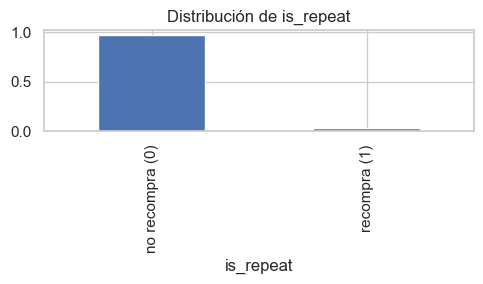

In [14]:
# A) is_churn por ventana: degeneración a través de poblaciones (snapshot demo)
m=maestra
pob={'Todos':m, 'recencia<=90d':m[m.recencia<=90], 'freq>=2 (recurrentes)':m[m.frecuencia>=2],
     'recencia<=90 & freq>=2':m[(m.recencia<=90)&(m.frecuencia>=2)]}
degen=pd.DataFrame({'n':[len(v) for v in pob.values()],
                    'tasa_churn_%':[round(v.is_churn.mean()*100,2) for v in pob.values()]},
                   index=pob.keys())
print('A) is_churn por ventana (H=90, corte demo) — DEGENERADO:'); print(degen)
print()
print('B) is_repeat (propensión a recompra) — TARGET RECOMENDADO:')
print('   tasa positiva:', round(clientes['is_repeat'].mean()*100,2),'%  | n=',len(clientes))
ax=clientes['is_repeat'].value_counts(normalize=True).rename({0:'no recompra (0)',1:'recompra (1)'}).plot(
    kind='bar', figsize=(5,3), title='Distribución de is_repeat'); plt.tight_layout(); plt.show()

## 13. Poblaciones y manejo del desbalance

Con clase positiva ~3 %, la *accuracy* es engañosa → se reportan **recall, F1 y AUC**, y se
maneja el desbalance con `class_weight`. Dos universos:

In [15]:
pobA=clientes
pobB=clientes[clientes['valor'].notna()]  # con 1er pedido con valor (elegibles a modelar)
comp=pd.DataFrame({
    'clientes':[len(pobA),len(pobB)],
    '% del total':[100, round(100*len(pobB)/len(pobA),1)],
    'tasa_recompra_%':[round(pobA.is_repeat.mean()*100,2), round(pobB.is_repeat.mean()*100,2)],
}, index=['A) Población completa','B) Con 1er pedido completo'])
print(comp)
print('\nRecomendación: población completa con class_weight balanceado;')
print('métricas: recall y AUC de la clase positiva (recompra), nunca accuracy.')

                            clientes  % del total  tasa_recompra_%
A) Población completa          94990        100.0             3.04
B) Con 1er pedido completo     94983        100.0             3.04

Recomendación: población completa con class_weight balanceado;
métricas: recall y AUC de la clase positiva (recompra), nunca accuracy.


## 14. Contraste de hipótesis

H1 y H2 se evalúan sobre el churn por ventana (son mecánicas); H3, H4 y H5 sobre el target
recomendado **`is_repeat`**. Las variables de experiencia (entrega, reseña) se contrastan y
**se descartan como predictores de recompra**, con advertencia del artefacto de medias-estrellas.

H1 Recencia  -> mediana activo=129 | churn=177  (↑recencia ⇒ ↑churn)
H2 Frecuencia-> entre recurrentes (freq>=2) la tasa de churn baja a 98.1% vs 99.4% global


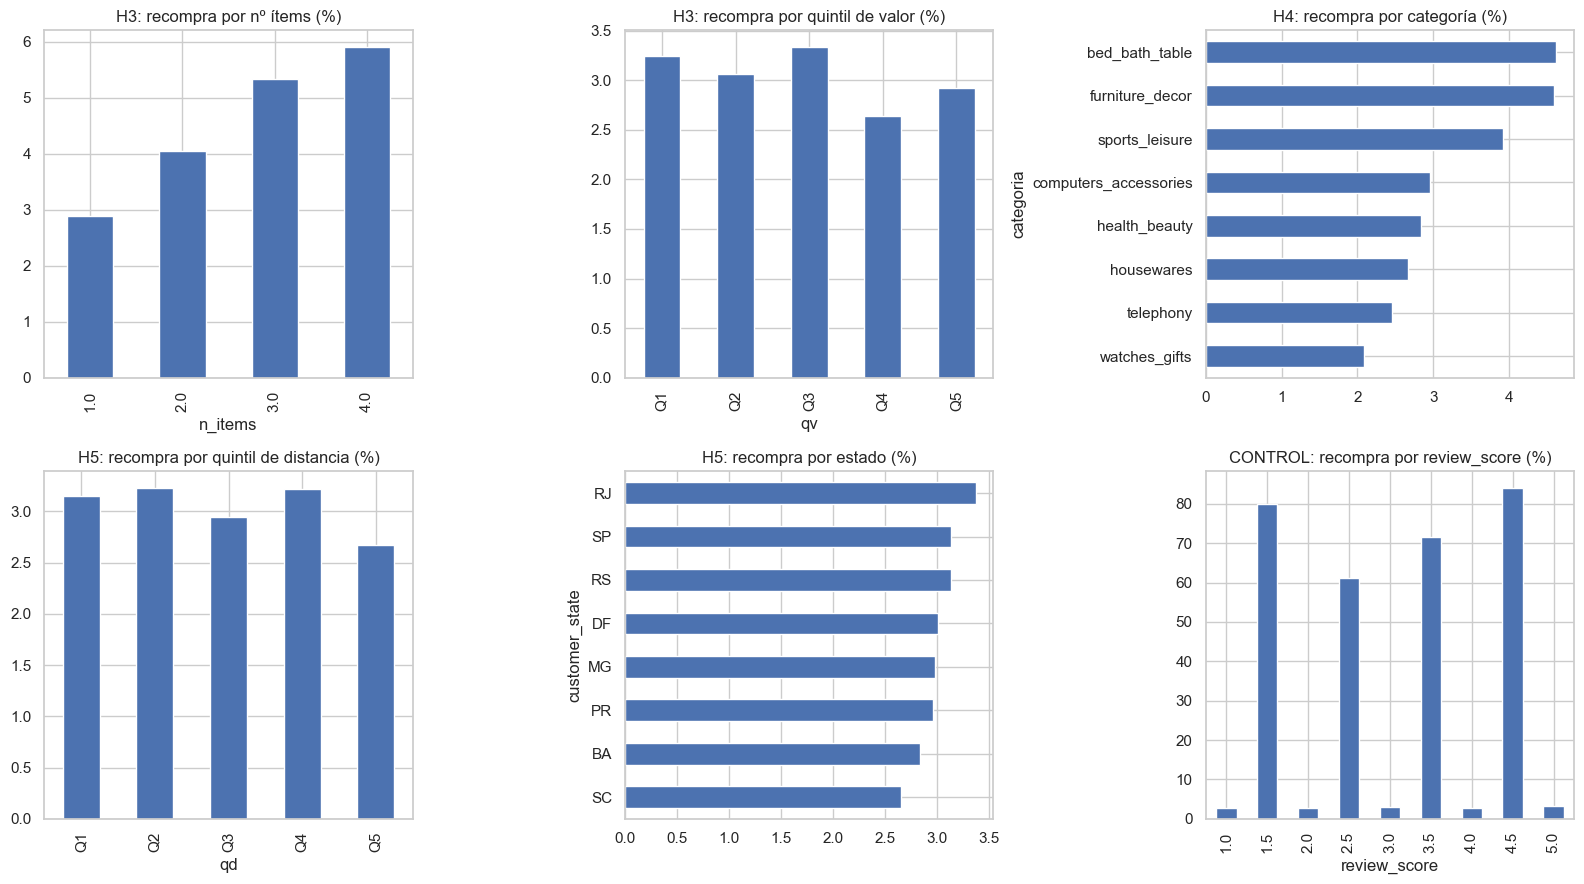

CONTROL entrega tardía -> recompra: puntual=3.12% | tardía=2.67%  (sin efecto)
⚠ Artefacto de medias-estrellas: NO usar la reseña MEDIA del cliente como predictor de
  recompra; las medias fraccionarias solo existen para clientes con varios pedidos (fuga).


In [16]:
# --- H1 recencia, H2 frecuencia (sobre churn por ventana) ---
print('H1 Recencia  -> mediana activo={:.0f} | churn={:.0f}  (↑recencia ⇒ ↑churn)'.format(
    maestra.groupby('is_churn')['recencia'].median().get(0,np.nan),
    maestra.groupby('is_churn')['recencia'].median().get(1,np.nan)))
print('H2 Frecuencia-> entre recurrentes (freq>=2) la tasa de churn baja a {:.1f}% vs {:.1f}% global'.format(
    maestra[maestra.frecuencia>=2]['is_churn'].mean()*100, maestra['is_churn'].mean()*100))

# --- H3/H4/H5 + controles sobre is_repeat ---
c=clientes
fig,ax=plt.subplots(2,3,figsize=(16,9))
# H3 nº ítems / valor
c.groupby(c['n_items'].clip(upper=4))['is_repeat'].mean().mul(100).plot(kind='bar',ax=ax[0,0]); ax[0,0].set_title('H3: recompra por nº ítems (%)')
c.assign(qv=pd.qcut(c['valor'],5,labels=['Q1','Q2','Q3','Q4','Q5'])).groupby('qv')['is_repeat'].mean().mul(100).plot(kind='bar',ax=ax[0,1]); ax[0,1].set_title('H3: recompra por quintil de valor (%)')
# H4 categoria (top8)
top8=c['categoria'].value_counts().head(8).index
c[c.categoria.isin(top8)].groupby('categoria')['is_repeat'].mean().mul(100).sort_values().plot(kind='barh',ax=ax[0,2]); ax[0,2].set_title('H4: recompra por categoría (%)')
# H5 distancia / estado
c.assign(qd=pd.qcut(c['dist_km'],5,labels=['Q1','Q2','Q3','Q4','Q5'])).groupby('qd')['is_repeat'].mean().mul(100).plot(kind='bar',ax=ax[1,0]); ax[1,0].set_title('H5: recompra por quintil de distancia (%)')
tops=c['customer_state'].value_counts().head(8).index
c[c.customer_state.isin(tops)].groupby('customer_state')['is_repeat'].mean().mul(100).sort_values().plot(kind='barh',ax=ax[1,1]); ax[1,1].set_title('H5: recompra por estado (%)')
# CONTROL: entrega tardía y reseña (descartadas)
ctrl=pd.DataFrame({'entrega_tardia':c.groupby(c['tardio'])['is_repeat'].mean()*100})
c.groupby('review_score')['is_repeat'].mean().mul(100).plot(kind='bar',ax=ax[1,2]); ax[1,2].set_title('CONTROL: recompra por review_score (%)')
plt.tight_layout(); plt.show()
print('CONTROL entrega tardía -> recompra: puntual={:.2f}% | tardía={:.2f}%  (sin efecto)'.format(
    c[c.tardio==0]['is_repeat'].mean()*100, c[c.tardio==1]['is_repeat'].mean()*100))
print('⚠ Artefacto de medias-estrellas: NO usar la reseña MEDIA del cliente como predictor de')
print('  recompra; las medias fraccionarias solo existen para clientes con varios pedidos (fuga).')

## 15. Correlaciones y multicolinealidad

Correlación de las features del primer pedido con el target `is_repeat` (insumo para Sprint 2).

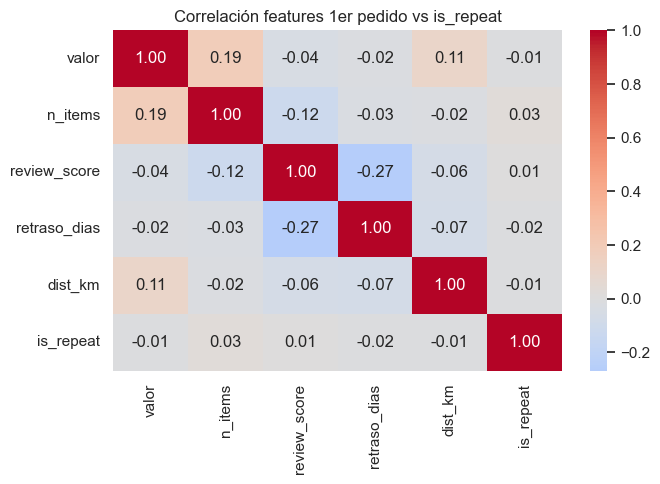

retraso_dias   -0.015
dist_km        -0.013
valor          -0.011
review_score    0.005
n_items         0.028
Name: is_repeat, dtype: float64

In [17]:
corr=clientes[['valor','n_items','review_score','retraso_dias','dist_km','is_repeat']].corr()
plt.figure(figsize=(7,5)); sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlación features 1er pedido vs is_repeat'); plt.tight_layout(); plt.show()
corr['is_repeat'].drop('is_repeat').sort_values().round(3)

## 16. Partición temporal preliminar (out-of-time)

Para `is_repeat`, la partición se hace por **fecha del primer pedido**: el modelo se entrena
con clientes antiguos y se evalúa con clientes posteriores, sin fuga.

In [18]:
corte_tr=pd.Timestamp('2018-01-31')
tr=clientes[clientes['order_purchase_timestamp']<=corte_tr]
te=clientes[clientes['order_purchase_timestamp']>corte_tr]
print(pd.DataFrame({'particion':['train (1er pedido <= 2018-01-31)','test (posterior)'],
                    'n':[len(tr),len(te)],
                    'tasa_recompra_%':[round(tr.is_repeat.mean()*100,2), round(te.is_repeat.mean()*100,2)]}))
print('\nNota: la tasa de recompra del test es menor porque su ventana de observación es más corta')
print('(menos tiempo para volver) — limitación temporal a considerar en el modelado.')

                          particion      n  tasa_recompra_%
0  train (1er pedido <= 2018-01-31)  50029             4.07
1                  test (posterior)  44961             1.89

Nota: la tasa de recompra del test es menor porque su ventana de observación es más corta
(menos tiempo para volver) — limitación temporal a considerar en el modelado.


## 17. Baseline técnico y de negocio

Baseline del target recomendado `is_repeat` (out-of-time): `DummyClassifier` vs regresión
logística con `class_weight`. Se contrasta con la degeneración de `is_churn`.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

feat=['valor','n_items','review_score','retraso_dias','dist_km']
Xtr,ytr=tr[feat],tr['is_repeat']; Xte,yte=te[feat],te['is_repeat']
pipe=Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler()),
               ('clf',LogisticRegression(max_iter=1000,class_weight='balanced',random_state=RANDOM_STATE))])
pipe.fit(Xtr,ytr); p=pipe.predict_proba(Xte)[:,1]; yhat=(p>=0.5).astype(int)
dummy=DummyClassifier(strategy='most_frequent').fit(Xtr,ytr)
print('--- Baseline técnico: target is_repeat (test out-of-time) ---')
print(f'Dummy        -> recall={recall_score(yte,dummy.predict(Xte)):.3f}  AUC=0.500')
print(f'LogReg       -> recall={recall_score(yte,yhat):.3f}  AUC={roc_auc_score(yte,p):.3f}')
print('  (señal débil: las features del 1er pedido explican poco la recompra)')
print('\n--- Contraste: is_churn por ventana es degenerado ---')
print(f'  tasa de churn (corte demo): {maestra.is_churn.mean():.3f}  -> AUC de cualquier modelo ~0.5')
print('\n--- Baseline de negocio ---')
print(f'Tasa de recompra: {clientes.is_repeat.mean():.4f}')
print(f'Valor histórico de clientes que recompran: R$ {clientes.loc[clientes.is_repeat==1,"valor"].sum():,.0f}')
print(f'Tasa de retención (no recompra): {1-clientes.is_repeat.mean():.4f}')

--- Baseline técnico: target is_repeat (test out-of-time) ---
Dummy        -> recall=0.000  AUC=0.500
LogReg       -> recall=0.527  AUC=0.545
  (señal débil: las features del 1er pedido explican poco la recompra)

--- Contraste: is_churn por ventana es degenerado ---
  tasa de churn (corte demo): 0.994  -> AUC de cualquier modelo ~0.5

--- Baseline de negocio ---
Tasa de recompra: 0.0304
Valor histórico de clientes que recompran: R$ 422,932
Tasa de retención (no recompra): 0.9696


## 18. Conclusiones y decisiones del Sprint 1

- **Estructura dominante:** 96,96 % de los clientes compra una sola vez (3,04 % recompra).
- **`is_churn` por ventana es degenerado** (~97-99 % en toda población) -> se conserva solo como
  métrica de negocio (tasa de retención), no como target de modelado.
- **Target del MVP: `is_repeat`** (propensión a recompra), desbalanceado pero accionable.
- **Hipótesis:** H1 (recencia) y H2 (historial) son mecánicas/dominantes; H4 (categoría) tiene
  señal moderada; H3 (características del 1er pedido) y H5 (geografía/distancia) aportan señal
  débil. **Entrega y reseña se descartan como predictores de recompra** (variables de control).
- **Señal global débil:** baseline de recompra AUC ~ 0,54 -> Sprint 2 debe priorizar feature
  engineering (RFM dinámico, comportamiento multi-pedido) mas que la calidad puntual del servicio.
- **`H = 90`** justificado por el tiempo a la 2a compra (68 % <= 90 días); partición out-of-time
  por fecha del primer pedido.
- **Handoff a Sprint 2:** `build_customer_table(t,H)` (snapshot) y la tabla `clientes` (1er
  pedido + `is_repeat`) son la base del pipeline reproducible.

## 19. Verificación y reproducibilidad

In [20]:
# 1) Sin fuga temporal en el snapshot
obs_chk=orders_enriched[orders_enriched['order_purchase_timestamp']<=FECHA_CORTE_DEMO]
assert obs_chk['order_purchase_timestamp'].max()<=FECHA_CORTE_DEMO, 'Fuga: feature usa datos > t'
# 2) Targets binarios
assert set(maestra['is_churn'].unique())<={0,1} and set(clientes['is_repeat'].unique())<={0,1}, 'Target no binario'
# 3) Grano correcto
assert maestra.index.is_unique and clientes.index.is_unique, 'Indice de cliente duplicado'
# 4) Coherencia de tasas con el EDA
assert abs(clientes['is_repeat'].mean()-0.0304)<0.01, 'Tasa de recompra fuera de lo esperado'
assert maestra['is_churn'].mean()>0.95, 'is_churn deberia ser degenerado (~99%)'
# 5) Particion temporal sin solape
assert tr['order_purchase_timestamp'].max()<=te['order_purchase_timestamp'].min(), 'Solape train/test'
print('OK - Todas las verificaciones pasaron. Notebook reproducible top-to-bottom.')

OK - Todas las verificaciones pasaron. Notebook reproducible top-to-bottom.
